## Lokalizacja punktu w przestrzeni dwuwymiarowej – metoda separatorów

### Cezary Szczepanek, Patryk Opala

In [1]:
import numpy as np
from graph import *
import tkinter as tk
from tkinter import messagebox, simpledialog
import json


# Aplikacja do zadawania podziału (Graf)

In [ ]:
class GraphEditor:
    def __init__(self, root):
        self.root = root
        self.root.title("Edytor Podziału Poligonowego")
        
        self.canvas = tk.Canvas(root, width=800, height=600, bg="white")
        self.canvas.pack(fill=tk.BOTH, expand=True)
        
        self.vertices = []
        self.edges = []
        self.selected_vertex = None
        
        self.setup_menu()
        
        self.canvas.bind("<Button-1>", self.on_click)
        self.root.bind("<Escape>", lambda e: self.deselect())

    def setup_menu(self):
        menu_frame = tk.Frame(self.root)
        menu_frame.pack(side=tk.TOP, fill=tk.X)
        
        tk.Label(menu_frame, text="LPM: Dodaj/Wybierz punkt | ESC: Odznacz").pack(side=tk.LEFT, padx=10)
        tk.Button(menu_frame, text="Zapisz do JSON", command=self.save_to_json).pack(side=tk.RIGHT, padx=5)
        tk.Button(menu_frame, text="Wyczyść", command=self.clear_all).pack(side=tk.RIGHT, padx=5)

    def on_click(self, event):
        x, y = event.x, event.y
        clicked_vertex = self.find_vertex(x, y)
        
        if clicked_vertex is not None:
            if self.selected_vertex is None:
                self.selected_vertex = clicked_vertex
                self.highlight_vertex(clicked_vertex, "red")
            elif self.selected_vertex != clicked_vertex:
                self.add_edge_dialog(self.selected_vertex, clicked_vertex)
                self.deselect()
        else:
            cartesian_y = 600 - y 
            v_id = len(self.vertices)
            self.vertices.append({'id': v_id, 'x': x, 'y': cartesian_y, 'canvas_x': x, 'canvas_y': y})
            self.draw_vertex(x, y, v_id)

    def find_vertex(self, x, y):
        for v in self.vertices:
            if (v['canvas_x'] - x)**2 + (v['canvas_y'] - y)**2 < 150:
                return v['id']
        return None

    def add_edge_dialog(self, v1, v2):
        lp = simpledialog.askstring("Wielokąt", f"Nazwa wielokąta po LEWEJ stronie krawędzi (od v{v1} do v{v2}):", initialvalue="Zewnetrzny")
        rp = simpledialog.askstring("Wielokąt", f"Nazwa wielokąta po PRAWEJ stronie krawędzi (od v{v1} do v{v2}):", initialvalue="Wielokat_A")
        
        if lp and rp:
            self.edges.append({'v1': v1, 'v2': v2, 'lp': lp, 'rp': rp})
            self.draw_edge(v1, v2)

    def draw_vertex(self, x, y, v_id):
        self.canvas.create_oval(x-5, y-5, x+5, y+5, fill="black", tags=f"v{v_id}")
        self.canvas.create_text(x+12, y-12, text=f"v{v_id}", font=("Arial", 10, "bold"))

    def draw_edge(self, v1_id, v2_id):
        v1 = self.vertices[v1_id]
        v2 = self.vertices[v2_id]
        # Rysujemy strzałkę, żeby było widać kierunek zadawania krawędzi (ważne dla lewo/prawo)
        self.canvas.create_line(v1['canvas_x'], v1['canvas_y'], v2['canvas_x'], v2['canvas_y'], 
                                arrow=tk.LAST, width=2, fill="blue")

    def highlight_vertex(self, v_id, color):
        self.canvas.itemconfig(f"v{v_id}", fill=color)

    def deselect(self):
        if self.selected_vertex is not None:
            self.highlight_vertex(self.selected_vertex, "black")
            self.selected_vertex = None

    def save_to_json(self):
        data = {
            "vertices": [{"id": v['id'], "x": v['x'], "y": v['y']} for v in self.vertices],
            "edges": self.edges
        }
        with open("graph_data.json", "w") as f:
            json.dump(data, f, indent=4)
        messagebox.showinfo("Sukces", "Graf zapisany do pliku graph_data.json!")

    def clear_all(self):
        if messagebox.askyesno("Potwierdzenie", "Czy na pewno chcesz wyczyścić cały graf?"):
            self.canvas.delete("all")
            self.vertices = []
            self.edges = []
            self.selected_vertex = None

if __name__ == "__main__":
    root = tk.Tk()
    app = GraphEditor(root)
    root.mainloop()

In [ ]:
def regularize_graph(graph: Graph):
    sorted_v = graph.get_sorted_vertices()
    if not sorted_v:
        return
    
    v_min = sorted_v[0]
    v_max = sorted_v[-1]
    
    # Naprawa wierzchołków SPLIT (brak wejść od dołu)
    for v in sorted_v:
        if v == v_min or v == v_max: continue
            
        if len(v.in_edges) == 0 and len(v.out_edges) > 0:
            sorted_out = graph.get_sorted_out_edges(v)
            # Obszar "pod" wierzchołkiem split to lewa strona jego lewej krawędzi
            inherited_poly = sorted_out[0].left_poly
            
            potential_partners = [u for u in sorted_v if u.y < v.y]
            if potential_partners:
                partner = max(potential_partners, key=lambda u: u.y)
                graph.add_edge(partner.id, v.id, left_poly=inherited_poly, right_poly=inherited_poly)
                print(f"Regularyzacja: SPLIT {v.id} dziedziczy '{inherited_poly}'")

    # Naprawa wierzchołków MERGE (brak wyjść w górę)
    for v in sorted_v:
        if v == v_min or v == v_max: continue
            
        if len(v.out_edges) == 0 and len(v.in_edges) > 0:
            sorted_in = graph.get_sorted_in_edges(v)
            # Obszar "nad" wierzchołkiem merge to prawa strona jego lewej krawędzi
            inherited_poly = sorted_in[0].right_poly
            
            potential_partners = [u for u in sorted_v if u.y > v.y]
            if potential_partners:
                partner = min(potential_partners, key=lambda u: u.y)
                graph.add_edge(v.id, partner.id, left_poly=inherited_poly, right_poly=inherited_poly)
                print(f"Regularyzacja: MERGE {v.id} dziedziczy '{inherited_poly}'")

In [ ]:
def balance_weights(graph):
    """
    Równoważy wagi krawędzi (Weight Balancing).
    Używa lokalnego parametru 'graph', a nie zmiennych globalnych.
    """
    #  Reset i inicjalizacja wag
    for edge in graph.edges:
        edge.weight = 1

    sorted_v = graph.get_sorted_vertices()
    n = len(sorted_v)
    
    # Przejście w górę (Forward Pass)
    for i in range(0, n - 1):
        v = sorted_v[i]
        if v.total_in_weight > v.total_out_weight:
            out_edges = graph.get_sorted_out_edges(v)
            if out_edges:
                # Dociążamy najbardziej lewą krawędź wychodzącą
                out_edges[0].weight += (v.total_in_weight - v.total_out_weight)

    # Przejście w dół (Backward Pass)
    sorted_v_reverse = list(reversed(sorted_v))
    for i in range(0, n - 1):
        v = sorted_v_reverse[i]
        if v.total_out_weight > v.total_in_weight:
            in_edges = graph.get_sorted_in_edges(v)
            if in_edges:
                # Dociążamy najbardziej lewą krawędź wchodzącą
                in_edges[0].weight += (v.total_out_weight - v.total_in_weight)
    
    print("Wagi zbalansowane poprawnie.")

In [5]:
def create_chain(g: Graph):
    sorted_v = g.get_sorted_vertices()
    num_chains = sorted_v[0].total_out_weight
    chains = [[] for _ in range(num_chains)]

    for chain in range(num_chains):
        v = sorted_v[0]
        while v != sorted_v[-1]:
            edges = g.get_sorted_out_edges(v)
            selected_edge = None

            for edge in edges:
                if edge.weight != 0:
                    edge.weight -= 1
                    edge.chains.append(chain)
                    selected_edge = edge
                    break
            
            if selected_edge:
                chains[chain].append(selected_edge)
                v = selected_edge.end
            else:
                print("Nie zbalansowany graf")
                return 
                

    return chains            
            

In [ ]:
def find_edge_in_chain(y: float, chain: List[Edge]) -> Optional[Edge]:
    low = 0
    high = len(chain) - 1
    
    while low <= high:
        mid = (low + high) // 2
        edge = chain[mid]
        
        # Sprawdzamy czy punkt y mieści się w przedziale y krawędzi
        if edge.start.y <= y <= edge.end.y:
            return edge
        elif y < edge.start.y:
            high = mid - 1
        else:
            low = mid + 1
    return None

def is_left_of_edge(p_x: float, p_y: float, edge: Edge) -> bool:
    """
    Zwraca True, jeśli punkt (p_x, p_y) leży po lewej stronie krawędzi 'edge'.
    Krawędź jest skierowana od edge.start do edge.end.
    """
    # Wektor krawędzi (v1) i wektor do punktu (v2)
    v1_x, v1_y = edge.end.x - edge.start.x, edge.end.y - edge.start.y
    v2_x, v2_y = p_x - edge.start.x, p_y - edge.start.y
    
    # Iloczyn wektorowy 2D
    det = v1_x * v2_y - v1_y * v2_x
    
    return det > 0


def locate_point(px: float, py: float, chains: List[List[Edge]]):

    if not chains or len(chains) == 0 or len(chains[0]) == 0:
        return "Błąd: Brak danych o łańcuchach (graf nie został poprawnie przetworzony)"
    
    # Sprawdzenie zakresu Y 
    y_min = chains[0][0].start.y
    y_max = chains[0][-1].end.y
    if py < y_min or py > y_max:
        return "Punkt poza obszarem (Y)"

    low = 0
    high = len(chains) - 1
    
    # Zmienne do zapamiętania ostatniego wyniku
    last_edge = None
    last_was_left = False

    while low <= high:
        mid = (low + high) // 2
        chain = chains[mid]
        edge = find_edge_in_chain(py, chain)
        
        if edge is None:
            return "Błąd: Brak krawędzi na tej wysokości"

        last_edge = edge # Zapamiętujemy krawędź do odczytu poly
        if is_left_of_edge(px, py, edge):
            last_was_left = True
            high = mid - 1
        else:
            last_was_left = False
            low = mid + 1

    # Odczytujemy nazwę wielokąta na podstawie ostatniego porównania
    if last_was_left:
        return f"Punkt znajduje się w: {last_edge.left_poly}"
    else:
        return f"Punkt znajduje się w: {last_edge.right_poly}"

## Funkcje z wizualizacjami

In [ ]:
from bitalg.visualizer.main import Visualizer

def visualize_all_chains(chains, graph):
    vis = Visualizer()
    vis.add_title('Dekompozycja na łańcuchy monotoniczne')
    vis.add_grid()
    vis.axis_equal() 
    
    colors = ["red", "blue", "green", "orange", "purple", "magenta", "cyan", "brown"]
    
    # Rysujemy tło
    for edge in graph.edges:
        vis.add_line_segment(((edge.start.x, edge.start.y), (edge.end.x, edge.end.y)), color="lightgray")
    
    # Rysujemy łańcuchy z offsetem
    for i, chain in enumerate(chains):
        color = colors[i % len(colors)]
        offset = i * 1.5 
        
        segments = []
        for edge in chain:
            seg = ((edge.start.x + offset, edge.start.y), (edge.end.x + offset, edge.end.y))
            segments.append(seg)
        
        vis.add_line_segment(segments, color=color) 
            
    return vis

In [ ]:
def locate_point_vis(px: float, py: float, chains: List[List[Edge]], graph: Graph):
    vis = Visualizer()
    vis.add_title(f'Lokalizacja punktu ({px}, {py})')
    vis.axis_equal()
    vis.add_grid()
    
    for edge in graph.edges:
        color = "lightgray" if edge.left_poly == edge.right_poly else "black"
        vis.add_line_segment(((edge.start.x, edge.start.y), (edge.end.x, edge.end.y)), color=color)
    
    vis.add_point((px, py), color="red")
    
    low, high = 0, len(chains) - 1
    last_edge, last_was_left = None, False
    current_search_elements = [] 

    while low <= high:
        # Czyszczenie klatki
        for elem in current_search_elements:
            vis.remove_figure(elem)
        current_search_elements = []

        mid = (low + high) // 2
        chain = chains[mid]
        
        # Podświetlenie łańcucha
        for e in chain:
            seg_ref = vis.add_line_segment(((e.start.x, e.start.y), (e.end.x, e.end.y)), color="cyan")
            current_search_elements.append(seg_ref)
        
        edge = find_edge_in_chain(py, chain)
        if edge:
            # Podświetlenie krawędzi decyzyjnej
            comp_ref = vis.add_line_segment(((edge.start.x, edge.start.y), (edge.end.x, edge.end.y)), color="magenta")
            current_search_elements.append(comp_ref)
            
            last_edge = edge
            if is_left_of_edge(px, py, edge):
                last_was_left = True
                high = mid - 1
            else:
                last_was_left = False
                low = mid + 1

    # Finalna klatka
    for elem in current_search_elements: vis.remove_figure(elem)
    vis.add_line_segment(((last_edge.start.x, last_edge.start.y), (last_edge.end.x, last_edge.end.y)), color="green")
    
    res_text = f"Punkt w: {last_edge.left_poly if last_was_left else last_edge.right_poly}"
    return res_text, vis

# Wczytujemy zadany podział i uruchamiamy pipeline

In [ ]:
def run_point_location_pipeline(filename, test_px, test_py):
    with open(filename, 'r') as f:
        data = json.load(f)
    
    g = Graph()
    
    id_to_vertex = {}
    for v_data in data['vertices']:
        v = g.add_vertex(v_data['x'], v_data['y'])
        id_to_vertex[v_data['id']] = v
        
    for e in data['edges']:
        u = id_to_vertex.get(e['v1'])
        v = id_to_vertex.get(e['v2'])
        
        if u and v:
            edge = g.add_edge(u, v, left_poly=e['lp'], right_poly=e['rp'])
        else:
            print(f"BŁĄD: Nie znaleziono wierzchołków {e['v1']} lub {e['v2']}")

    if len(g.edges) == 0:
        print("BŁĄD: Graf nie ma krawędzi!")
        return g, []

    regularize_graph(g)
    balance_weights(g)
    
    chains = create_chain(g)
    
    if not chains or len(chains) == 0:
        print("BŁĄD: Nie utworzono żadnych łańcuchów! Sprawdź wagowanie.")
        return g, []
        
    return g, chains



In [28]:
g2, chains2 = run_point_location_pipeline("irregular_cup.json",0,0)

px, py = 600,750

print("WYNIKI LOKALIZACJI:")
print(locate_point(px,py,chains2))

Regularyzacja: SPLIT 1 dziedziczy 'Dol_Kielicha'
Wagi zbalansowane poprawnie.
WYNIKI LOKALIZACJI:
Punkt znajduje się w: Gora_Kielicha


## Pipeline z wizualizacją

In [11]:
def run_full_visualization_pipeline(filename, px, py):
    with open(filename, 'r') as f:
        data = json.load(f)
    
    g = Graph()
    id_to_vertex = {}
    for v_data in data['vertices']:
        v = g.add_vertex(v_data['x'], v_data['y'])
        id_to_vertex[v_data['id']] = v
        
    for e in data['edges']:
        g.add_edge(id_to_vertex[e['v1']], id_to_vertex[e['v2']], 
                   left_poly=e['lp'], right_poly=e['rp'])

    
    regularize_graph(g)
    balance_weights(g)
    chains = create_chain(g)
    
    if not chains:
        print("BŁĄD: Nie udało się utworzyć łańcuchów.")
        return None

    
    print(f"\nGenerowanie wizualizacji dla punktu ({px}, {py})...")
    
    vis_chains = visualize_all_chains(chains, g)
    
    result_text, vis_search = locate_point_vis(px, py, chains, g)
    
    print("-" * 30)
    print(f"WYNIK LOKALIZACJI: {result_text}")
    print("-" * 30)
    
    return vis_chains, vis_search

Regularyzacja: SPLIT 1 dziedziczy 'Dol_Kielicha'
Wagi zbalansowane poprawnie.

Generowanie wizualizacji dla punktu (600, 750)...
------------------------------
WYNIK LOKALIZACJI: Punkt w: Gora_Kielicha
------------------------------
Prezentacja wszystkich łańcuchów (dekompozycja grafu):

Proces wyszukiwania binarnego (lokalizacja punktu):
Wyświetlam zapisaną animację:


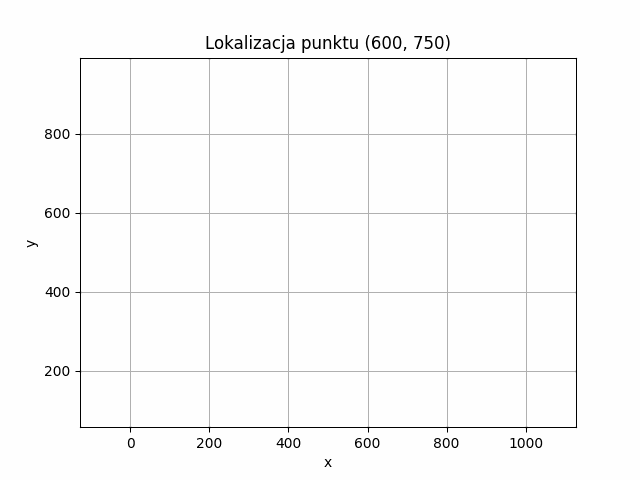

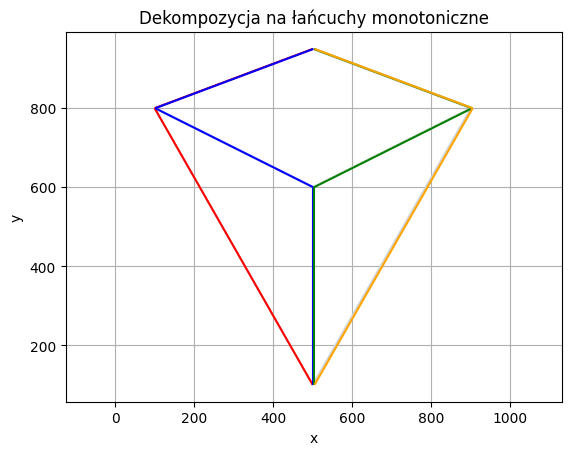

In [29]:
test_px, test_py = 600, 750 

visualizations = run_full_visualization_pipeline("irregular_cup.json", test_px, test_py)

if visualizations:
    vis_chains, vis_search = visualizations

    # WIZUALIZACJA 1: STATYCZNA 
    print("Prezentacja wszystkich łańcuchów (dekompozycja grafu):")
    vis_chains.show() 

    # WIZUALIZACJA 2: ANIMOWANA 
    print("\nProces wyszukiwania binarnego (lokalizacja punktu):")
    from IPython.display import Image, display

    vis_search.save_gif(filename='wynik_lokalizacji', interval=300)

    print("Wyświetlam zapisaną animację:")
    display(Image(filename='wynik_lokalizacji.gif'))

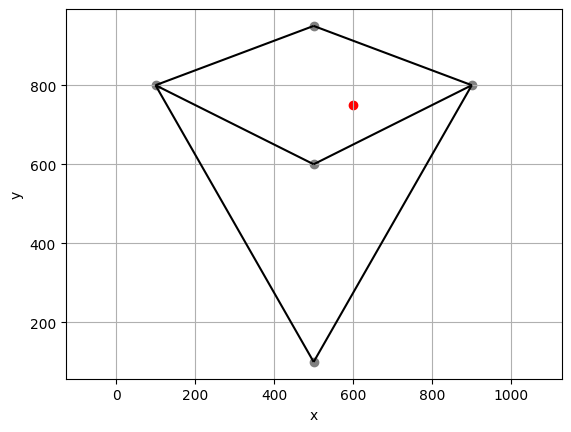

In [27]:
import json

def plot_raw_graph(filename, px, py):
    with open(filename, 'r') as f:
        data = json.load(f)
    
    vis = Visualizer()
    vis.add_grid()
    vis.axis_equal()
    
    vertices = {v['id']: (v['x'], v['y']) for v in data['vertices']}
    
    for e in data['edges']:
        v1_coords = vertices[e['v1']]
        v2_coords = vertices[e['v2']]
        # Format: ((x1, y1), (x2, y2))
        vis.add_line_segment((v1_coords, v2_coords), color='black')
    
    points_list = list(vertices.values())
    vis.add_point(points_list, color='gray')
    
    vis.add_point((px, py), color='red')
    
    vis.show()
    
    return vis

plot_raw_graph("irregular_cup.json", 600, 750)

## Testy wydajnościowe

In [ ]:
import time
import matplotlib.pyplot as plt

def generate_performance_graph(n_chains):
    g = Graph()
    v_start = g.add_vertex(500, 0)
    v_end = g.add_vertex(500, 1000)
    
    # Tworzymy n_chains ścieżek, co wygeneruje dokładnie n_chains łańcuchów
    for i in range(n_chains):
        v_mid = g.add_vertex(i * 10, 500)
        g.add_edge(v_start, v_mid, "Zewnetrzny", f"Obszar_{i}")
        g.add_edge(v_mid, v_end, f"Obszar_{i}", "Zewnetrzny")
    
    balance_weights(g)
    chains = create_chain(g)
    return g, chains

# Parametry testu
sizes = [100, 500, 1000, 2500, 5000, 7500, 10000]
times = []

print("Rozpoczynam testy wydajnościowe...")
for n in sizes:
    g_bench, chains_bench = generate_performance_graph(n)
    
    # Mierzymy czas 1000 lokalizacji dla uśrednienia wyniku
    start_time = time.time()
    for _ in range(1000):
        locate_point(250, 500, chains_bench)
    end_time = time.time()
    
    avg_time = (end_time - start_time) / 1000
    times.append(avg_time)
    print(f"Łańcuchy: {n} | Średni czas zapytania: {avg_time:.8f} s")

# Opcjonalny wykres w notebooku
plt.plot(sizes, times, marker='o')
plt.title("Złożoność czasowa lokalizacji punktu")
plt.xlabel("Liczba łańcuchów")
plt.ylabel("Czas [s]")
plt.grid(True)
plt.show()